In [1]:
!unzip /content/characters.zip

Archive:  /content/characters.zip
   creating: content/characters/
   creating: content/characters/Falcon/
  inflating: content/characters/Falcon/5.png3096938_0.png  
  inflating: content/characters/Falcon/2.png3172505_1.png  
  inflating: content/characters/Falcon/4.png3483377_4.png  
   creating: content/characters/Winter-Soldier/
  inflating: content/characters/Winter-Soldier/2.png3172505_2.png  
  inflating: content/characters/Winter-Soldier/15.png3468060_1.png  
  inflating: content/characters/Winter-Soldier/4.png3483377_0.png  
  inflating: content/characters/Winter-Soldier/11.png3432315_5.png  
  inflating: content/characters/Winter-Soldier/16.png2976460_0.png  
  inflating: content/characters/Winter-Soldier/15.png3468060_2.png  
  inflating: content/characters/Winter-Soldier/9.png3001942_1.png  
  inflating: content/characters/Winter-Soldier/14.png3571381_3.png  
  inflating: content/characters/Winter-Soldier/11.png3432315_1.png  
  inflating: content/characters/Winter-Soldier/

In [7]:
drive_pth = "/content/drive/MyDrive"
import os

os.makedirs(os.path.join(drive_pth,"Aug_Characters"),exist_ok=True)

In [8]:
output_dir = "/content/drive/MyDrive/Aug_Characters"
os.makedirs(os.path.join(output_dir, 'Black-Widow_train'), exist_ok=True)
os.makedirs(os.path.join(output_dir, 'Black-Widow_test'), exist_ok=True)
os.makedirs(os.path.join(output_dir, 'Falcon_train'), exist_ok=True)
os.makedirs(os.path.join(output_dir, 'Falcon_test'), exist_ok=True)
os.makedirs(os.path.join(output_dir, 'Mary-Jane_train'), exist_ok=True)
os.makedirs(os.path.join(output_dir, 'Mary-Jane_test'), exist_ok=True)
os.makedirs(os.path.join(output_dir, 'Ned_train'), exist_ok=True)
os.makedirs(os.path.join(output_dir, 'Ned_test'), exist_ok=True)
os.makedirs(os.path.join(output_dir, 'Peter_train'), exist_ok=True)
os.makedirs(os.path.join(output_dir, 'Peter_test'), exist_ok=True)
os.makedirs(os.path.join(output_dir, 'Spiderman_train'), exist_ok=True)
os.makedirs(os.path.join(output_dir, 'Spiderman_test'), exist_ok=True)
os.makedirs(os.path.join(output_dir, 'Stanley_train'), exist_ok=True)
os.makedirs(os.path.join(output_dir, 'Stanley_test'), exist_ok=True)
os.makedirs(os.path.join(output_dir, 'Steve-Rogers_train'), exist_ok=True)
os.makedirs(os.path.join(output_dir, 'Steve-Rogers_test'), exist_ok=True)
os.makedirs(os.path.join(output_dir, 'Tony_train'), exist_ok=True)
os.makedirs(os.path.join(output_dir, 'Tony_test'), exist_ok=True)
os.makedirs(os.path.join(output_dir, 'War-Machine_train'), exist_ok=True)
os.makedirs(os.path.join(output_dir, 'War-Machine_test'), exist_ok=True)
os.makedirs(os.path.join(output_dir, 'Winter-Soldier_train'), exist_ok=True)
os.makedirs(os.path.join(output_dir, 'Winter-Soldier_test'), exist_ok=True)

In [9]:
import numpy as np
from PIL import Image


def load_and_resize_images(input_dir, size=(512, 512)):
    images = []
    for img_name in os.listdir(input_dir):
        img_path = os.path.join(input_dir, img_name)
        img = Image.open(img_path).convert('RGB')
        img = img.resize(size)
        images.append(np.array(img))
    return np.array(images)

In [16]:
chars = []
for char in os.listdir('/content/content/characters'):
  indi = os.path.join('/content/content/characters', char)
  ind_class = load_and_resize_images(indi)
  chars.append([ind_class,indi[28:]])

In [17]:
for i in range(len(chars)):
  print(chars[i][1],end='\n')

War-Machine
Steve-Rogers
Spiderman
Peter
Falcon
Ned
Winter-Soldier
Stanley
Mary-Jane
Black-Widow
Tony


In [18]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.05,
    height_shift_range=0.05,
    shear_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

augmented_images = []

for i in range(len(chars)):
  pth = chars[i][1]
  train_pth = os.path.join(output_dir,pth+'_train')
  test_pth = os.path.join(output_dir,pth+'_test')
  lenn = 0
  for img in chars[i][0]:
    img = img.reshape((1,)+img.shape)
    cou = 0
    for bth in datagen.flow(img,batch_size=1):
      im = Image.fromarray(bth[0].astype('uint8'))
      # augmented_images.append(bth[0].astype('uint8'))
      if cou < 20: im.save(os.path.join(train_pth,f'{lenn}_{cou}.png'))
      elif cou >=20 and cou < 25: im.save(os.path.join(test_pth,f'{lenn}_{cou}.png'))
      if cou >= 25: break
      cou += 1
    lenn += 1

In [2]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.layers import BatchNormalization, Activation, Input
from tensorflow.keras.models import Model
from tensorflow.keras.applications import VGG16

In [3]:
train_ds = keras.utils.image_dataset_from_directory(
    directory = "/content/drive/MyDrive/Aug_Characters/train",
    labels="inferred",
    label_mode="int",
    batch_size=32,
    image_size=(224, 224)
)
val_ds = keras.utils.image_dataset_from_directory(
    directory = "/content/drive/MyDrive/Aug_Characters/test",
    labels="inferred",
    label_mode="int",
    batch_size=32,
    image_size=(224, 224)
)

Found 1860 files belonging to 11 classes.
Found 465 files belonging to 11 classes.


In [4]:
def process(image,label):
    image = tf.cast(image/255,tf.float32)
    return image,label

train_ds = train_ds.map(process)
val_ds = val_ds.map(process)

In [5]:
from tensorflow.keras.layers import Dense,Flatten

def build_vgg(input_shape):
  inputs = Input(input_shape)

  vgg16 = VGG16(include_top=False, weights="imagenet", input_tensor=inputs)
  for layer in vgg16.layers:
    layer.trainable = False

  fl = Flatten()(vgg16.output)
  d1 = Dense(512, Activation("relu"))(fl)
  d2 = Dense(256, Activation("relu"))(d1)
  outputs = Dense(11, activation="softmax")(d2)

  model = Model(inputs, outputs, name="VGG16_classify")
  return model

In [6]:
input_shape = (224, 224, 3)
model = build_vgg(input_shape)
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


In [7]:
model.summary()

Model: "VGG16_classify"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv1 (Conv2D)                │ (None, 224, 224, 64)        │           1,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv2 (Conv2D)                │ (None, 224, 224, 64)        │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_pool (MaxPooling2D)           │ (None, 112, 112, 64)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv1 (Conv2D)                │ (None, 112, 112, 128)       │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv2 (Conv2D)                │ (None, 112, 112, 128)       │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_pool (MaxPooling2D)           │ (None, 56, 56, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv1 (Conv2D)                │ (None, 56, 56, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv2 (Conv2D)                │ (None, 56, 56, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv3 (Conv2D)                │ (None, 56, 56, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_pool (MaxPooling2D)           │ (None, 28, 28, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv1 (Conv2D)                │ (None, 28, 28, 512)         │       1,180,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv2 (Conv2D)                │ (None, 28, 28, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv3 (Conv2D)                │ (None, 28, 28, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_pool (MaxPooling2D)           │ (None, 14, 14, 512)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv1 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv2 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv3 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_pool (MaxPooling2D)           │ (None, 7, 7, 512)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 25088)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 512)                 │      12,845,568 │
├──────────────────────────────────────┼─────────────────────────────┼──────────────

 Total params: 27,694,411 (105.65 MB)

 Trainable params: 12,979,723 (49.51 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [8]:
history = model.fit(train_ds,epochs=10,validation_data=val_ds)

Epoch 1/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 968s 16s/step - accuracy: 0.4722 - loss: 3.2702 - val_accuracy: 0.9978 - val_loss: 0.0298
Epoch 2/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 43s 478ms/step - accuracy: 1.0000 - loss: 0.0095 - val_accuracy: 1.0000 - val_loss: 0.0074
Epoch 3/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 43s 506ms/step - accuracy: 1.0000 - loss: 0.0025 - val_accuracy: 1.0000 - val_loss: 0.0031
Epoch 4/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 28s 476ms/step - accuracy: 1.0000 - loss: 8.8879e-04 - val_accuracy: 1.0000 - val_loss: 0.0016
Epoch 5/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 31s 535ms/step - accuracy: 1.0000 - loss: 3.4623e-04 - val_accuracy: 1.0000 - val_loss: 7.8594e-04
Epoch 6/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 37s 464ms/step - accuracy: 1.0000 - loss: 1.5825e-04 - val_accuracy: 1.0000 - val_loss: 5.2188e-04
Epoch 7/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 43s 506ms/step - accuracy: 1.0000 - loss: 8.7013e-05 - val_accuracy: 1.0000 - val_loss: 4.1635e-04
Epoch 8/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 38s 450ms/step - accuracy: 1.000

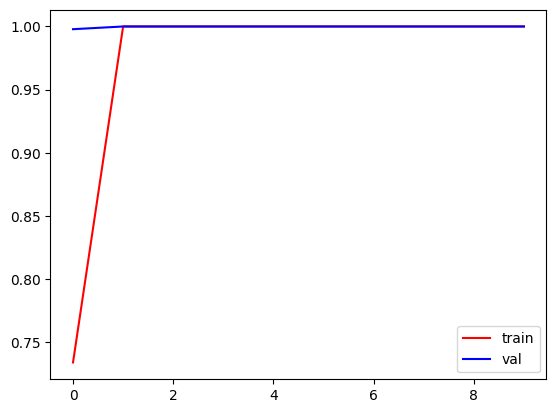

In [21]:
import matplotlib.pyplot as plt
plt.plot(history.history['accuracy'],color='red',label='train')
plt.plot(history.history['val_accuracy'],color='blue',label='val')
plt.legend()
plt.show()

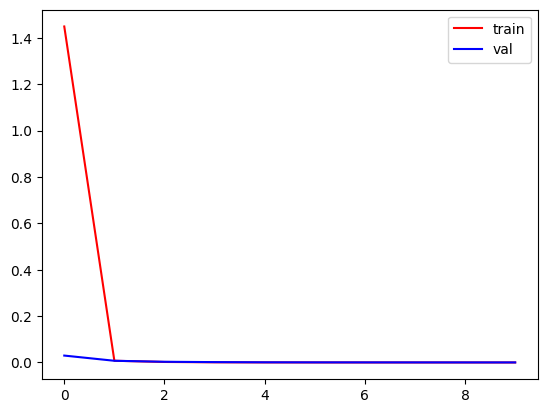

In [22]:
import matplotlib.pyplot as plt
plt.plot(history.history['loss'],color='red',label='train')
plt.plot(history.history['val_loss'],color='blue',label='val')
plt.legend()
plt.show()

In [9]:
model.save('vgg_charx224.h5')

In [20]:
import os
from PIL import Image
from keras.preprocessing.image import img_to_array
import numpy as np
output_dir = "/content/drive/MyDrive/Aug_Characters/test"

for cl in os.listdir(output_dir):
  img_path = os.listdir(os.path.join(output_dir, cl))[0]
  # print(img_path,end='\n')
  img = Image.open(os.path.join(os.path.join(output_dir, cl),img_path)).convert('RGB')
  img = img_to_array(img)
  img = tf.image.resize(img, [224, 224])
  img = np.expand_dims(img,axis=0)
  img = img/255
  print(cl,np.argmax(model.predict(img)),end='\n')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
Black-Widow_test 0
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
Falcon_test 1
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
Mary-Jane_test 2
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
Ned_test 3
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
Peter_test 4
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
Spiderman_test 5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
Stanley_test 6
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
Steve-Rogers_test 7
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
Tony_test 8
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
War-Machine_test 9
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
Winter-Soldier_test 10
